In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, f1_score, 
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle

# Load the data and the model.
df = pd.read_csv('data/disasters_clean.csv')

# Create a severity score.
df['severity_score'] = (
    np.log1p(df['Total Deaths']) +
    np.log1p(df['Total Affected'])
)

# Create classes.
df['severity_class'] = pd.cut(
    df['severity_score'],
    bins=3,
    labels=[0,1,2]
).astype(int)

# Encode Disaster Type
le = LabelEncoder()
df['Disaster_Type_Encoded'] = le.fit_transform(df['Disaster Type'])

# Features
X = df[['Year', 'Total Deaths', 'Total Affected',
        "Total Damages ('000 US$)", 'Disaster_Type_Encoded']]
y = df['severity_class']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Load the model.
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

y_pred = model.predict(X_test)

print("✅ Setup complete!")
print(f"Test samples: {len(y_test)}")

✅ Setup complete!
Test samples: 3226


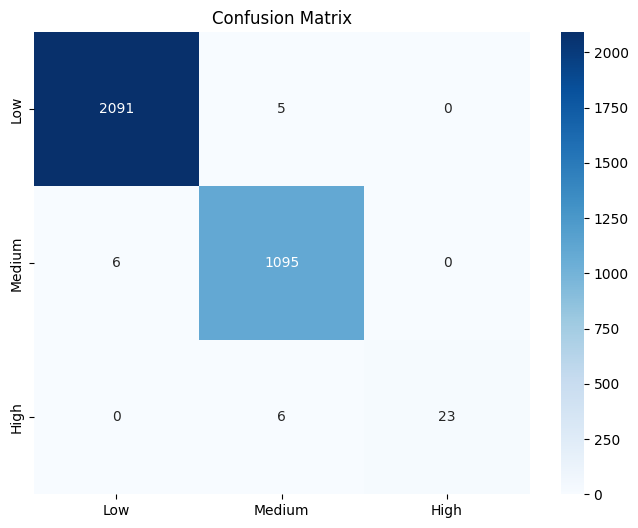

F1 Score: 0.9946

Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      2096
      Medium       0.99      0.99      0.99      1101
        High       1.00      0.79      0.88        29

    accuracy                           0.99      3226
   macro avg       1.00      0.93      0.96      3226
weighted avg       0.99      0.99      0.99      3226



In [2]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'])
plt.title('Confusion Matrix')
plt.savefig('data/confusion_matrix.png')
plt.show()

# F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Low','Medium','High']))

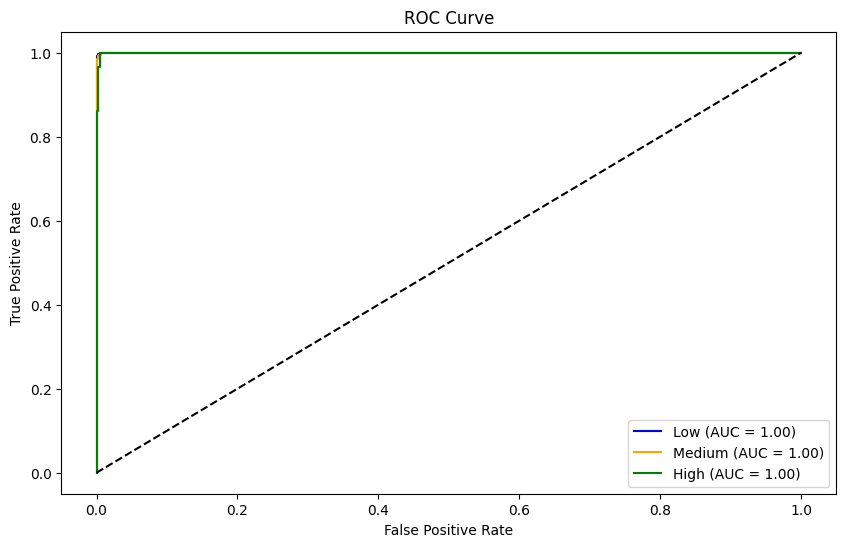

✅ ROC Curve saved!

=== Edge Cases Testing ===

Disaster: Flood        | Deaths:        0 | Severity: Low 🟢
Disaster: Earthquake   | Deaths:   999999 | Severity: High 🔴
Disaster: Drought      | Deaths:      100 | Severity: Medium 🟡
Disaster: Storm        | Deaths:        1 | Severity: Low 🟢


In [3]:
# ROC Curve
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_proba = model.predict_proba(X_test)

plt.figure(figsize=(10,6))
colors = ['blue', 'orange', 'green']
classes = ['Low', 'Medium', 'High']

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_pred_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i],
             label=f'{classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('data/roc_curve.png')
plt.show()
print("✅ ROC Curve saved!")

# Edge Cases
print("\n=== Edge Cases Testing ===\n")
edge_cases = [
    ("Flood", 0, 0, 0, 2020),
    ("Earthquake", 999999, 9999999, 99999999, 1900),
    ("Drought", 100, 5000, 100000, 2021),
    ("Storm", 1, 1, 1, 1950),
]

for disaster, deaths, affected, damages, year in edge_cases:
    encoded = le.transform([disaster])[0]
    pred = model.predict([[year, deaths, affected, damages, encoded]])[0]
    labels = {0: "Low 🟢", 1: "Medium 🟡", 2: "High 🔴"}
    print(f"Disaster: {disaster:12} | Deaths: {deaths:8} | Severity: {labels[pred]}")

In [4]:
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score)

print("=" * 50)
print("   MODEL EVALUATION METRICS")
print("=" * 50)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy:    {accuracy*100:.2f}%")

# Precision
precision = precision_score(y_test, y_pred, average='weighted')
print(f"✅ Precision:   {precision*100:.2f}%")

# Sensitivity/Recall
recall = recall_score(y_test, y_pred, average='weighted')
print(f"📊 Sensitivity/Recall: {recall*100:.2f}%")

# F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"🔥 F1 Score:    {f1*100:.2f}%")

print("\n" + "=" * 50)
print("   CLASS-WISE METRICS")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['Low','Medium','High']))

   MODEL EVALUATION METRICS

🎯 Accuracy:    99.47%
✅ Precision:   99.47%
📊 Sensitivity/Recall: 99.47%
🔥 F1 Score:    99.46%

   CLASS-WISE METRICS
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      2096
      Medium       0.99      0.99      0.99      1101
        High       1.00      0.79      0.88        29

    accuracy                           0.99      3226
   macro avg       1.00      0.93      0.96      3226
weighted avg       0.99      0.99      0.99      3226



In [ ]:
print("=" * 50)
print("   DISASTER TYPE WISE ACCURACY")
print("=" * 50)

# Add disaster type in the test data.
X_test_copy = X_test.copy()
X_test_copy['Actual'] = y_test.values
X_test_copy['Predicted'] = y_pred
X_test_copy['Disaster_Type'] = le.inverse_transform(
    X_test_copy['Disaster_Type_Encoded'].astype(int))

# Calculate accuracy for each disaster type
for disaster in X_test_copy['Disaster_Type'].unique():
    subset = X_test_copy[X_test_copy['Disaster_Type'] == disaster]
    acc = accuracy_score(subset['Actual'], subset['Predicted'])
    print(f"{disaster:25} → Accuracy: {acc*100:.2f}%")

   DISASTER TYPE WISE ACCURACY
Storm                     → Accuracy: 99.68%
Flood                     → Accuracy: 99.06%
Earthquake                → Accuracy: 99.67%
Landslide                 → Accuracy: 99.34%
Extreme temperature       → Accuracy: 100.00%
Wildfire                  → Accuracy: 98.89%
Drought                   → Accuracy: 100.00%
Epidemic                  → Accuracy: 99.66%
Insect infestation        → Accuracy: 100.00%
Volcanic activity         → Accuracy: 100.00%
Mass movement (dry)       → Accuracy: 100.00%
Impact                    → Accuracy: 100.00%
